<a href="https://colab.research.google.com/github/Bunkhuoch-Ann/Side_Quests_simple/blob/main/Soccer_match_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd "/content/drive/MyDrive/Football_model"

/content/drive/MyDrive/Football_model


In [ ]:
import pandas as pd

df = pd.read_csv('PremierLeague.csv')
display(df.head())

,MatchID,Season,MatchWeek,Date,Time,HomeTeam,AwayTeam,FullTimeHomeTeamGoals,FullTimeAwayTeamGoals,FullTimeResult,...,MarketMaxAwayTeam,MarketAvgHomeTeam,MarketAvgDraw,MarketAvgAwayTeam,MarketMaxOver2.5Goals,MarketMaxUnder2.5Goals,MarketAvgOver2.5Goals,MarketAvgUnder2.5Goals,HomeTeamPoints,AwayTeamPoints
0,1993-1994_Arsenal_Coventry,1993-1994,1,1993-08-14,NaN,Arsenal,Coventry,0,3,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3
1,1993-1994_Aston Villa_QPR,1993-1994,1,1993-08-14,NaN,Aston Villa,QPR,4,1,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0
2,1993-1994_Chelsea_Blackburn,1993-1994,1,1993-08-14,NaN,Chelsea,Blackburn,1,2,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3
3,1993-1994_Liverpool_Sheffield Weds,1993-1994,1,1993-08-14,NaN,Liverpool,Sheffield Weds,2,0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0
4,1993-1994_Man City_Leeds,1993-1994,1,1993-08-14,NaN,Man City,Leeds,1,1,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1


Text(0, 0.5, 'Frequency')

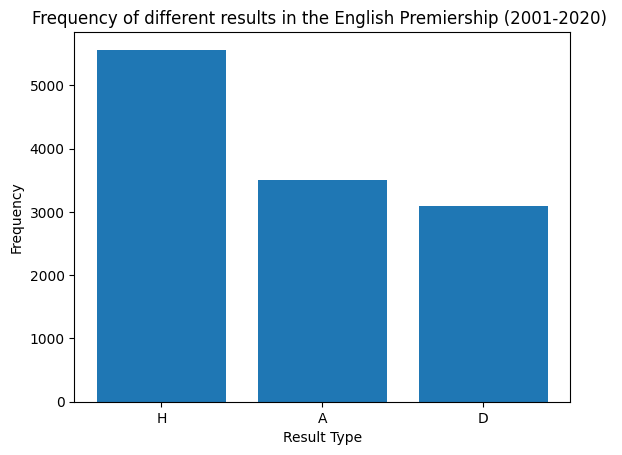

In [ ]:
import matplotlib.pyplot as plt
fig, chart = plt.subplots()
data = df['FullTimeResult'].value_counts()
points = data.index
frequency = data.values
chart.bar(points, frequency)
chart.set_title('Frequency of different results in the English Premiership (2001-2020) ')
chart.set_xlabel('Result Type')
chart.set_ylabel('Frequency')

In [ ]:
Home_team = df["HomeTeam"]
Away_team = df["AwayTeam"]

In [ ]:
Home_team.value_counts()

,count
HomeTeam,
Arsenal,605
Man United,605
Everton,605
Tottenham,605
Chelsea,604
Liverpool,604
Newcastle,566
Aston Villa,549
West Ham,545


In [ ]:
Away_team.value_counts()

,count
AwayTeam,
Man United,606
Everton,605
Arsenal,605
Chelsea,604
Tottenham,603
Liverpool,603
Newcastle,568
West Ham,548
Aston Villa,546


In [ ]:
# Identify all unique teams
all_teams = pd.concat([df['HomeTeam'], df['AwayTeam']]).unique()

# Create a mapping from team name to a numerical ID
team_to_id = {team: i for i, team in enumerate(all_teams, start=1)}

# Display the mapping
print("Mapping of teams to numerical IDs:")
for team, team_id in team_to_id.items():
    print(f"{team}: {team_id}")

Mapping of teams to numerical IDs:
Arsenal: 1
Aston Villa: 2
Chelsea: 3
Liverpool: 4
Man City: 5
Newcastle: 6
Oldham: 7
Sheffield United: 8
Southampton: 9
West Ham: 10
Norwich: 11
Tottenham: 12
Everton: 13
Ipswich: 14
Leeds: 15
Wimbledon: 16
Blackburn: 17
Coventry: 18
Man United: 19
QPR: 20
Sheffield Weds: 21
Swindon: 22
Crystal Palace: 23
Leicester: 24
Nott'm Forest: 25
Bolton: 26
Middlesbrough: 27
Derby: 28
Sunderland: 29
Barnsley: 30
Charlton: 31
Watford: 32
Bradford: 33
Fulham: 34
Birmingham: 35
West Brom: 36
Portsmouth: 37
Wolves: 38
Wigan: 39
Reading: 40
Hull: 41
Stoke: 42
Burnley: 43
Blackpool: 44
Swansea: 45
Cardiff: 46
Bournemouth: 47
Brighton: 48
Huddersfield: 49
Brentford: 50
Luton: 51


In [ ]:
training1_df = df[['MatchWeek', 'HomeTeam', 'AwayTeam', 'FullTimeResult', "Date"]].copy()
display(training1_df.head())

,MatchWeek,HomeTeam,AwayTeam,FullTimeResult,Date
0,1,Arsenal,Coventry,A,1993-08-14
1,1,Aston Villa,QPR,H,1993-08-14
2,1,Chelsea,Blackburn,A,1993-08-14
3,1,Liverpool,Sheffield Weds,H,1993-08-14
4,1,Man City,Leeds,D,1993-08-14


In [ ]:
training_df = training1_df.copy()
training_df['HomeTeam'] = training1_df['HomeTeam'].map(team_to_id)
training_df['AwayTeam'] = training1_df['AwayTeam'].map(team_to_id)

# Convert 'Date' column to datetime objects
training_df["Date"] = pd.to_datetime(training_df["Date"])

training_df["MatchDay"] = training_df["Date"].dt.day_name()

all_day = (training_df["MatchDay"]).unique()
day_to_id = {day: i for i, day in enumerate(all_day, start=1)}
training_df['MatchDay'] = training_df['MatchDay'].map(day_to_id)
display(training_df.head())

,MatchWeek,HomeTeam,AwayTeam,FullTimeResult,Date,MatchDay
0,1,1,18,A,1993-08-14,1
1,1,2,20,H,1993-08-14,1
2,1,3,17,A,1993-08-14,1
3,1,4,21,H,1993-08-14,1
4,1,5,15,D,1993-08-14,1


In [ ]:
# Display the mapping
print("Mapping of Days to numerical IDs:")
for day, day_id in day_to_id.items():
    print(f"{day}: {day_id}")

Mapping of Days to numerical IDs:
Saturday: 1
Sunday: 2
Monday: 3
Tuesday: 4
Wednesday: 5
Friday: 6
Thursday: 7


In [ ]:
# def calculate_features(df):
#     # Ensure the dataframe is sorted by date to calculate cumulative stats correctly
#     df['Date'] = pd.to_datetime(df['Date'])
#     df = df.sort_values(by=['Date', 'Time', 'MatchID']).reset_index(drop=True)

#     # Initialize columns for stats
#     df['HomeTeamWins'] = (df['FullTimeResult'] == 'H').astype(int)
#     df['AwayTeamWins'] = (df['FullTimeResult'] == 'A').astype(int)
#     df['HomeTeamDraws'] = (df['FullTimeResult'] == 'D').astype(int)
#     df['AwayTeamDraws'] = (df['FullTimeResult'] == 'D').astype(int)
#     df['HomeTeamLosses'] = (df['FullTimeResult'] == 'A').astype(int)
#     df['AwayTeamLosses'] = (df['FullTimeResult'] == 'H').astype(int)
#     df['HomeTeamGoalsScored'] = df['FullTimeHomeTeamGoals']
#     df['AwayTeamGoalsScored'] = df['FullTimeAwayTeamGoals']
#     df['HomeTeamGoalsConceded'] = df['FullTimeAwayTeamGoals']
#     df['AwayTeamGoalsConceded'] = df['FullTimeHomeTeamGoals']
#     df['HomeTeamMatches'] = 1
#     df['AwayTeamMatches'] = 1

#     # Calculate cumulative overall stats
#     df['HomeTeamOverallWins'] = df.groupby('HomeTeam')['HomeTeamWins'].cumsum().shift(1).fillna(0)
#     df['AwayTeamOverallWins'] = df.groupby('AwayTeam')['AwayTeamWins'].cumsum().shift(1).fillna(0)
#     df['HomeTeamOverallMatches'] = df.groupby('HomeTeam')['HomeTeamMatches'].cumsum().shift(1).fillna(0)
#     df['AwayTeamOverallMatches'] = df.groupby('AwayTeam')['AwayTeamMatches'].cumsum().shift(1).fillna(0)
#     df['HomeTeamOverallGoalsScored'] = df.groupby('HomeTeam')['HomeTeamGoalsScored'].cumsum().shift(1).fillna(0)
#     df['AwayTeamOverallGoalsScored'] = df.groupby('AwayTeam')['AwayTeamGoalsScored'].cumsum().shift(1).fillna(0)
#     df['HomeTeamOverallGoalsConceded'] = df.groupby('HomeTeam')['HomeTeamGoalsConceded'].cumsum().shift(1).fillna(0)
#     df['AwayTeamOverallGoalsConceded'] = df.groupby('AwayTeam')['AwayTeamGoalsConceded'].cumsum().shift(1).fillna(0)

#     # Calculate overall win rates, handling division by zero
#     df['HomeTeamOverallWinRate'] = (df['HomeTeamOverallWins'] / df['HomeTeamOverallMatches']).fillna(0)
#     df['AwayTeamOverallWinRate'] = (df['AwayTeamOverallWins'] / df['AwayTeamOverallMatches']).fillna(0)

#     # Calculate cumulative current season stats
#     df['HomeTeamSeasonWins'] = df.groupby(['Season', 'HomeTeam'])['HomeTeamWins'].cumsum().shift(1).fillna(0)
#     df['AwayTeamSeasonWins'] = df.groupby(['Season', 'AwayTeam'])['AwayTeamWins'].cumsum().shift(1).fillna(0)
#     df['HomeTeamSeasonDraws'] = df.groupby(['Season', 'HomeTeam'])['HomeTeamDraws'].cumsum().shift(1).fillna(0)
#     df['AwayTeamSeasonDraws'] = df.groupby(['Season', 'AwayTeam'])['AwayTeamDraws'].cumsum().shift(1).fillna(0)
#     df['HomeTeamSeasonMatches'] = df.groupby(['Season', 'HomeTeam'])['HomeTeamMatches'].cumsum().shift(1).fillna(0)
#     df['AwayTeamSeasonMatches'] = df.groupby(['Season', 'AwayTeam'])['AwayTeamMatches'].cumsum().shift(1).fillna(0)
#     df['HomeTeamSeasonGoalsScored'] = df.groupby(['Season', 'HomeTeam'])['HomeTeamGoalsScored'].cumsum().shift(1).fillna(0)
#     df['AwayTeamSeasonGoalsScored'] = df.groupby(['Season', 'AwayTeam'])['AwayTeamGoalsScored'].cumsum().shift(1).fillna(0)
#     df['HomeTeamSeasonGoalsConceded'] = df.groupby(['Season', 'HomeTeam'])['HomeTeamGoalsConceded'].cumsum().shift(1).fillna(0)
#     df['AwayTeamSeasonGoalsConceded'] = df.groupby(['Season', 'AwayTeam'])['AwayTeamGoalsConceded'].cumsum().shift(1).fillna(0)


#     # Calculate current season win rates, handling division by zero
#     df['HomeTeamSeasonWinRate'] = (df['HomeTeamSeasonWins'] / df['HomeTeamSeasonMatches']).fillna(0)
#     df['AwayTeamSeasonWinRate'] = (df['AwayTeamSeasonWins'] / df['AwayTeamSeasonMatches']).fillna(0)


#     # Calculate current season points
#     df['HomeTeamSeasonPoints'] = df['HomeTeamSeasonWins'] * 3 + df['HomeTeamSeasonDraws'] * 1
#     df['AwayTeamSeasonPoints'] = df['AwayTeamSeasonWins'] * 3 + df['AwayTeamSeasonDraws'] * 1


#     return df

# training_df_with_new_features = calculate_features(df.copy())

# # Merge the new features into the training_df based on the original index
# training_df['HomeTeamOverallGoalsScored'] = training_df_with_new_features['HomeTeamOverallGoalsScored']
# training_df['AwayTeamOverallGoalsScored'] = training_df_with_new_features['AwayTeamOverallGoalsScored']
# training_df['HomeTeamOverallGoalsConceded'] = training_df_with_new_features['HomeTeamOverallGoalsConceded']
# training_df['AwayTeamOverallGoalsConceded'] = training_df_with_new_features['AwayTeamOverallGoalsConceded']
# training_df['HomeTeamSeasonGoalsScored'] = training_df_with_new_features['HomeTeamSeasonGoalsScored']
# training_df['AwayTeamSeasonGoalsScored'] = training_df_with_new_features['AwayTeamSeasonGoalsScored']
# training_df['HomeTeamSeasonGoalsConceded'] = training_df_with_new_features['HomeTeamSeasonGoalsConceded']
# training_df['AwayTeamSeasonGoalsConceded'] = training_df_with_new_features['AwayTeamSeasonGoalsConceded']
# training_df['HomeTeamSeasonPoints'] = training_df_with_new_features['HomeTeamSeasonPoints']
# training_df['AwayTeamSeasonPoints'] = training_df_with_new_features['AwayTeamSeasonPoints']
# training_df['HomeTeamOverallWinRate'] = training_df_with_new_features['HomeTeamOverallWinRate']
# training_df['AwayTeamOverallWinRate'] = training_df_with_new_features['AwayTeamOverallWinRate']
# training_df['HomeTeamSeasonWinRate'] = training_df_with_new_features['HomeTeamSeasonWinRate']
# training_df['AwayTeamSeasonWinRate'] = training_df_with_new_features['AwayTeamSeasonWinRate']


# display(training_df.head())

In [ ]:
# Duplicate FullTimeResult column
training1_df["FullTimeResult1"] = training1_df["FullTimeResult"].copy()
training1_df["FullTimeResult2"] = training1_df["FullTimeResult"].copy()
training1_df["FullTimeResult3"] = training1_df["FullTimeResult"].copy()

result_mapping1 = {'D': 0, 'H': 0, 'A':1}
training_df['FullTimeResult1'] = training1_df['FullTimeResult1'].map(result_mapping1)

result_mapping2 = {'D': 1, 'H': 0, 'A':1}
training_df['FullTimeResult2'] = training1_df['FullTimeResult2'].map(result_mapping2)

result_mapping3 = {'H':0, 'D':2, 'A':1}
training_df['FullTimeResult3'] = training1_df['FullTimeResult3'].map(result_mapping3)

display(training_df.head())

,MatchWeek,HomeTeam,AwayTeam,FullTimeResult,Date,MatchDay,FullTimeResult1,FullTimeResult2,FullTimeResult3
0,1,1,18,A,1993-08-14,1,1,1,1
1,1,2,20,H,1993-08-14,1,0,0,0
2,1,3,17,A,1993-08-14,1,1,1,1
3,1,4,21,H,1993-08-14,1,0,0,0
4,1,5,15,D,1993-08-14,1,0,1,2


In [ ]:
# Get the list of columns
cols = training_df.columns.tolist()

cols.remove('FullTimeResult')
cols.remove('Date')
cols.remove('MatchWeek')
cols.append('MatchWeek')

cols.remove('MatchDay')
cols.append('MatchDay')

# Remove 'FullTimeResult' and add it to the end
cols.remove('FullTimeResult1')
cols.append('FullTimeResult1')

cols.remove('FullTimeResult2')
cols.append('FullTimeResult2')

cols.remove('FullTimeResult3')
cols.append('FullTimeResult3')

# Reindex the DataFrame with the new column order
training_df = training_df[cols]

display(training_df.head())

,HomeTeam,AwayTeam,MatchWeek,MatchDay,FullTimeResult1,FullTimeResult2,FullTimeResult3
0,1,18,1,1,1,1,1
1,2,20,1,1,0,0,0
2,3,17,1,1,1,1,1
3,4,21,1,1,0,0,0
4,5,15,1,1,0,1,2


In [ ]:
training_df.to_csv('training_data.csv', index=False)
print("Training data saved to 'training_data.csv'")

Training data saved to 'training_data.csv'


In [ ]:
display(training_df.head())

,HomeTeam,AwayTeam,MatchWeek,MatchDay,FullTimeResult1,FullTimeResult2,FullTimeResult3
0,1,18,1,1,1,1,1
1,2,20,1,1,0,0,0
2,3,17,1,1,1,1,1
3,4,21,1,1,0,0,0
4,5,15,1,1,0,1,2


In [ ]:
X = training_df.iloc[:, 0:-4] # Select only the 2nd and 3rd columns
y1 = training_df.iloc[:, -3]
y2 = training_df.iloc[:, -2]
y3 = training_df.iloc[:, -1]
display(X.head())
display(y1.head())
display(y2.head())
display(y3.head())

,HomeTeam,AwayTeam,MatchWeek
0,1,18,1
1,2,20,1
2,3,17,1
3,4,21,1
4,5,15,1


,FullTimeResult1
0,1
1,0
2,1
3,0
4,0


,FullTimeResult2
0,1
1,0
2,1
3,0
4,1


,FullTimeResult3
0,1
1,0
2,1
3,0
4,2


In [ ]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=42)

X2_train, X2_test, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=42)
X3_train, X3_test, y3_train, y3_test = train_test_split(X, y3, test_size=0.2, random_state=42)
print("Data split into training and testing sets.")
print(f"Shape of X1_train: {X1_train.shape}")
print(f"Shape of X1_test: {X1_test.shape}")
print(f"Shape of X2_train: {X2_train.shape}")
print(f"Shape of X2_test: {X2_test.shape}")
print(f"Shape of y1_train: {y1_train.shape}")
print(f"Shape of y1_test: {y1_test.shape}")
print(f"Shape of y2_train: {y2_train.shape}")
print(f"Shape of y2_test: {y2_test.shape}")

Data split into training and testing sets.
Shape of X1_train: (9728, 3)
Shape of X1_test: (2432, 3)
Shape of X2_train: (9728, 3)
Shape of X2_test: (2432, 3)
Shape of y1_train: (9728,)
Shape of y1_test: (2432,)
Shape of y2_train: (9728,)
Shape of y2_test: (2432,)


**Simple Models**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Use RandomForestClassifier instead of DecisionTreeClassifier
RFmodel1 = RandomForestClassifier(n_estimators=200, random_state=42) # Using 100 trees as you initially suggested
RFmodel2 = RandomForestClassifier(n_estimators=200, random_state=42) # Using 100 trees as you initially suggested
RFmodel3 = RandomForestClassifier(n_estimators=200, random_state=42) # Using 100 trees as you initially suggested

RFmodel1.fit(X1_train, y1_train)
RFmodel2.fit(X2_train, y2_train)
RFmodel3.fit(X3_train, y3_train)
print("Random Forest Classifier model trained successfully.")

Random Forest Classifier model trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y1_pred = RFmodel1.predict(X1_test)
y2_pred = RFmodel2.predict(X2_test)
y3_pred = RFmodel3.predict(X3_test)

accuracyRF1 = accuracy_score(y1_test, y1_pred)
accuracyRF2 = accuracy_score(y2_test, y2_pred)
accuracyRF3 = accuracy_score(y3_test, y3_pred)

print(f"Accuracy for Model 1: {accuracyRF1}")
print(f"Accuracy for Model 2: {accuracyRF2}")
print(f"Accuracy for Model 3: {accuracyRF3}")

# report = classification_report(y_test, y_pred)
# conf_matrix = confusion_matrix(y_test, y_pred)

# print("\nClassification Report:")
# print(report)
# print("\nConfusion Matrix:")
# print(conf_matrix)

Accuracy for Model 1: 0.6735197368421053
Accuracy for Model 2: 0.5822368421052632
Accuracy for Model 3: 0.4354440789473684


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the XGBoost Classifier
# Using objective='multi:softmax' for multi-class classification
# eval_metric='mlogloss' is suitable for multi-class
# Remap 2 -> 1 for binary classification
xgb_model1 = xgb.XGBClassifier(objective='multi:softmax', num_class=2, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model1.fit(X1_train, y1_train)

xgb_model2 = xgb.XGBClassifier(objective='multi:softmax', num_class=2, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model2.fit(X2_train, y2_train)

xgb_model3 = xgb.XGBClassifier(objective='multi:softmax', num_class=3, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model3.fit(X3_train, y3_train)


print("XGBoost model trained successfully.")

# Make predictions on the test set
y1_pred_xgb = xgb_model1.predict(X1_test)
y2_pred_xgb = xgb_model2.predict(X2_test)
y3_pred_xgb = xgb_model3.predict(X3_test)

# Evaluate the model
accuracy_xgb1 = accuracy_score(y1_test, y1_pred_xgb)
accuracy_xgb2 = accuracy_score(y2_test, y2_pred_xgb)
accuracy_xgb3 = accuracy_score(y3_test, y3_pred_xgb)

print(f"Accuracy for Model 1: {accuracy_xgb1}")
print(f"Accuracy for Model 2: {accuracy_xgb2}")
print(f"Accuracy for Model 3: {accuracy_xgb3}")

# report_xgb = classification_report(y_test, y_pred_xgb)
# conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

# print(f"\nXGBoost Accuracy: {accuracy_xgb}")
# print("\nXGBoost Classification Report:")
# print(report_xgb)
# print("\nXGBoost Confusion Matrix:")
# print(conf_matrix_xgb)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:12:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:12:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:12:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained successfully.
Accuracy for Model 1: 0.6924342105263158
Accuracy for Model 2: 0.5974506578947368
Accuracy for Model 3: 0.47574013157894735


In [ ]:
# def predict_match_outcome_simple(home_team, away_team, matchday, matchweek):
#     """Predicts the outcome of a football match using the trained Random Forest and XGBoost models."""

#     # Convert team names to their numerical IDs
#     try:
#         home_id = team_to_id[home_team]
#         away_id = team_to_id[away_team]
#         matchday_id = day_to_id[matchday]
#     except KeyError as e:
#         print(f"Error: Team '{e}' not found in the mapping.")
#         return None

#     # Prepare the input data for the models (Random Forest and XGBoost)
#     # The order of features should match the order used for training: HomeTeam, AwayTeam, MatchWeek
#     input_data = [[home_id, away_id, matchday_id, matchweek]]

#     # Predict using the Random Forest model
#     if 'model' in globals():
#         rf_pred = model.predict(input_data)
#         rf_proba = model.predict_proba(input_data) # Get prediction probabilities
#         # Define a mapping from predicted class to result string for Random Forest
#         rf_result_mapping = {0: 'Home win or Draw', 1: 'Away win'} # Assuming your RF model output 0 for Home, 1 for Away, 2 for Draw
#         print(f"Random Forest Prediction for {home_team} vs {away_team}:")
#         print("Predicted result:", rf_result_mapping[rf_pred[0]])
#         print("Prediction probabilities (Home win or Draw, Away win):", rf_proba[0]) # Display probabilities
#     else:
#         print("Random Forest model not found. Please train the model first.")

#     print("-" * 20) # Separator

#     # Predict using the XGBoost model
#     if 'xgb_model' in globals():
#         xgb_pred = xgb_model.predict(input_data)
#         xgb_proba = xgb_model.predict_proba(input_data) # Get prediction probabilities for XGBoost
#         # Define a mapping from predicted class to result string for XGBoost
#         # Adjust the mapping based on the actual output classes of your XGBoost model
#         xgb_result_mapping = {0: 'Home win or Draw', 1: 'Away win'} # Assuming your XGBoost model output 0 for Home, 1 for Away, 2 for Draw
#         print(f"XGBoost Prediction for {home_team} vs {away_team}:")
#         print("Predicted result:", xgb_result_mapping[xgb_pred[0]])
#         print("Prediction probabilities (Home win or Draw, Away win):", xgb_proba[0]) # Display probabilities for XGBoost
#     else:
#         print("XGBoost model not found. Please train the model first.")



def predict_match_outcome_simple(home_team, away_team, matchweek):
    """Predicts the outcome of a football match using the trained Random Forest and XGBoost models."""

    # Convert team names to their numerical IDs
    try:
        home_id = team_to_id[home_team]
        away_id = team_to_id[away_team]
    except KeyError as e:
        print(f"Error: Team '{e}' not found in the mapping.")
        return None

    # Prepare the input data for the models (Random Forest and XGBoost)
    # The order of features should match the order used for training: HomeTeam, AwayTeam, MatchWeek
    input_data = [[home_id, away_id, matchweek]]

    # Predict using the Random Forest model
    if 'RFmodel1' in globals():
        rf_pred = RFmodel1.predict(input_data)
        rf_proba = RFmodel1.predict_proba(input_data) # Get prediction probabilities
        # Define a mapping from predicted class to result string for Random Forest
        rf_result_mapping = {0: 'Home win or Draw', 2: 'Away win'} # Assuming your RF model output 0 for Home, 1 for Away, 2 for Draw
        print(f"Random Forest Prediction for {home_team} vs {away_team}:")
        print("Predicted result:", rf_result_mapping[rf_pred[0]])
        print("Prediction probabilities (Home win or Draw, Away win):", rf_proba[0]) # Display probabilities

    if 'RFmodel2' in globals():
        rf_pred = RFmodel2.predict(input_data)
        rf_proba = RFmodel2.predict_proba(input_data) # Get prediction probabilities
        # Define a mapping from predicted class to result string for Random Forest
        rf_result_mapping = {0: 'Home win', 2: 'Away win or Draw'} # Assuming your RF model output 0 for Home, 1 for Away, 2 for Draw
        print(f"Random Forest Prediction for {home_team} vs {away_team}:")
        print("Predicted result:", rf_result_mapping[rf_pred[0]])
        print("Prediction probabilities (Home win, Away win or Draw):", rf_proba[0]) # Display probabilities
    else:
        print("Random Forest model not found. Please train the model first.")

    print("-" * 20) # Separator

    # Predict using the XGBoost model
    if 'xgb_model1' in globals():
        xgb_pred = xgb_model1.predict(input_data)
        xgb_proba = xgb_model1.predict_proba(input_data) # Get prediction probabilities for XGBoost
        # Define a mapping from predicted class to result string for XGBoost
        # Adjust the mapping based on the actual output classes of your XGBoost model
        xgb_result_mapping = {0: 'Home win or Draw', 1: 'Away win'} # Assuming your XGBoost model output 0 for Home, 1 for Away, 2 for Draw
        print(f"XGBoost Prediction for {home_team} vs {away_team}:")
        print("Predicted result:", xgb_result_mapping[xgb_pred[0]])
        print("Prediction probabilities (Home win or Draw, Away win):", xgb_proba[0]) # Display probabilities for XGBoost

    if 'xgb_model2' in globals():
        xgb_pred = xgb_model2.predict(input_data)
        xgb_proba = xgb_model2.predict_proba(input_data) # Get prediction probabilities for XGBoost
        # Define a mapping from predicted class to result string for XGBoost
        # Adjust the mapping based on the actual output classes of your XGBoost model
        xgb_result_mapping = {0: 'Home win', 1: 'Away win or Draw'} # Assuming your XGBoost model output 0 for Home, 1 for Away, 2 for Draw
        print(f"XGBoost Prediction for {home_team} vs {away_team}:")
        print("Predicted result:", xgb_result_mapping[xgb_pred[0]])
        print("Prediction probabilities (Home win, Away win or Draw):", xgb_proba[0]) # Display probabilities for XGBoost
    else:
        print("XGBoost model not found. Please train the model first.")


# def predict_match_outcome_simple(home_team, away_team):
#     """Predicts the outcome of a football match using the trained Random Forest and XGBoost models."""

#     # Convert team names to their numerical IDs
#     try:
#         home_id = team_to_id[home_team]
#         away_id = team_to_id[away_team]
#     except KeyError as e:
#         print(f"Error: Team '{e}' not found in the mapping.")
#         return None

#     # Prepare the input data for the models (Random Forest and XGBoost)
#     # The order of features should match the order used for training: HomeTeam, AwayTeam, MatchWeek
#     input_data = [[home_id, away_id]]

#     # Predict using the Random Forest model
#     if 'model' in globals():
#         rf_pred = model.predict(input_data)
#         rf_proba = model.predict_proba(input_data) # Get prediction probabilities
#         # Define a mapping from predicted class to result string for Random Forest
#         rf_result_mapping = {0: 'Home win or Draw', 1: 'Away win'} # Assuming your RF model output 0 for Home, 1 for Away, 2 for Draw
#         print(f"Random Forest Prediction for {home_team} vs {away_team}:")
#         print("Predicted result:", rf_result_mapping[rf_pred[0]])
#         print("Prediction probabilities (Home win or Draw, Away win):", rf_proba[0]) # Display probabilities
#     else:
#         print("Random Forest model not found. Please train the model first.")

#     print("-" * 20) # Separator

#     # Predict using the XGBoost model
#     if 'xgb_model' in globals():
#         xgb_pred = xgb_model.predict(input_data)
#         xgb_proba = xgb_model.predict_proba(input_data) # Get prediction probabilities for XGBoost
#         # Define a mapping from predicted class to result string for XGBoost
#         # Adjust the mapping based on the actual output classes of your XGBoost model
#         xgb_result_mapping = {0: 'Home win or Draw', 1: 'Away win'} # Assuming your XGBoost model output 0 for Home, 1 for Away, 2 for Draw
#         print(f"XGBoost Prediction for {home_team} vs {away_team}:")
#         print("Predicted result:", xgb_result_mapping[xgb_pred[0]])
#         print("Prediction probabilities (Home win or Draw, Away win):", xgb_proba[0]) # Display probabilities for XGBoost
#     else:
#         print("XGBoost model not found. Please train the model first.")

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Example usage:
home_team_name = "Liverpool"
away_team_name = "Arsenal"
#matchday = 'Saturday'
matchweek_num = 3

# predict_match_outcome_simple(home_team_name, away_team_name, matchday, matchweek_num)
predict_match_outcome_simple(home_team_name, away_team_name, matchweek_num)
# predict_match_outcome_simple(home_team_name, away_team_name)

Random Forest Prediction for Liverpool vs Arsenal:
Predicted result: Home win or Draw
Prediction probabilities (Home win or Draw, Away win): [0.74598214 0.25401786]
Random Forest Prediction for Liverpool vs Arsenal:
Predicted result: Home win
Prediction probabilities (Home win, Away win or Draw): [0.73348214 0.26651786]
--------------------
XGBoost Prediction for Liverpool vs Arsenal:
Predicted result: Home win or Draw
Prediction probabilities (Home win or Draw, Away win): [0.8129971  0.18700296]
XGBoost Prediction for Liverpool vs Arsenal:
Predicted result: Away win or Draw
Prediction probabilities (Home win, Away win or Draw): [0.418592   0.58140796]


Mapping of teams to numerical IDs:
Arsenal: 1
Aston Villa: 2
Chelsea: 3
Liverpool: 4
Man City: 5
Newcastle: 6
Oldham: 7
Sheffield United: 8
Southampton: 9
West Ham: 10
Norwich: 11
Tottenham: 12
Everton: 13
Ipswich: 14
Leeds: 15
Wimbledon: 16
Blackburn: 17
Coventry: 18
Man United: 19
QPR: 20
Sheffield Weds: 21
Swindon: 22
Crystal Palace: 23
Leicester: 24
Nott'm Forest: 25
Bolton: 26
Middlesbrough: 27
Derby: 28
Sunderland: 29
Barnsley: 30
Charlton: 31
Watford: 32
Bradford: 33
Fulham: 34
Birmingham: 35
West Brom: 36
Portsmouth: 37
Wolves: 38
Wigan: 39
Reading: 40
Hull: 41
Stoke: 42
Burnley: 43
Blackpool: 44
Swansea: 45
Cardiff: 46
Bournemouth: 47
Brighton: 48
Huddersfield: 49
Brentford: 50
Luton: 51

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class BigBinaryRandomForest(BaseEstimator, ClassifierMixin):
    def __init__(self, model1=None, model2=None):
        self.model1 = model1
        self.model2 = model2

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        proba1 = self.model1.predict_proba(X)  # [p(H/D), p(A)]
        proba2 = self.model2.predict_proba(X)  # [p(H), p(D/A)]

        combined = []
        for p1, p2 in zip(proba1, proba2):
            pav = (p1 + p2) / 2
            combined.append(pav)
        return np.array(combined)

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)  # 0 = Home/Draw, 1 = Away/Draw


class BigBinaryXGBoost(BaseEstimator, ClassifierMixin):
    def __init__(self, model1=None, model2=None):
        self.model1 = model1
        self.model2 = model2

    def fit(self, X, y=None):
        return self  # models already trained

    def predict_proba(self, X):
        proba1 = self.model1.predict_proba(X)  # [p(H/D), p(A)]
        proba2 = self.model2.predict_proba(X)  # [p(H), p(D/A)]

        combined = []
        for p1, p2 in zip(proba1, proba2):
            pav = (p1 + p2) / 2
            combined.append(pav)
        return np.array(combined)

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)  # 0 = Home/Draw, 1 = Away/Draw


from sklearn.metrics import accuracy_score

def relaxed_accuracy(y_true, y_pred):
    correct = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == yp:
            correct += 1
        elif yt == 2 and yp == 0:  # true D, predicted H/Draw
            correct += 1
        elif yt == 2 and yp == 1:  # true D, predicted A/Draw
            correct += 1
    return correct / len(y_true)


In [ ]:
# # Prepare test labels in numeric format
# label_mapping = {'H':0, 'D':1, 'A':2}
# y_test_num = y3_test_original.map(label_mapping).values  # use the real y test (H/D/A)

# Big model predictions
big_modelRF = BigBinaryRandomForest(model1=RFmodel1, model2=RFmodel2)
y_pred_big = big_modelRF.predict(X3_test)

big_modelXGB = BigBinaryXGBoost(model1=xgb_model1, model2=xgb_model2)
y_pred_big_xgb = big_modelXGB.predict(X3_test)

# Accuracy
from sklearn.metrics import accuracy_score, classification_report
print("Big model accuracy (RF):", relaxed_accuracy(y3_test, y_pred_big))
print("Big model accuracy (XGBoost):", relaxed_accuracy(y3_test, y_pred_big_xgb))
# print(classification_report(y3_test, y_pred_big, target_names=["H","D","A"]))


Big model accuracy (RF): 0.7245065789473685
Big model accuracy (XGBoost): 0.7393092105263158


In [ ]:
def predict_match_outcome_big(home_team, away_team, matchweek):
    """Predicts the outcome of a football match using BigBinaryRandomForest and BigBinaryXGBoost models."""

    # --- Convert team names and matchweek into feature vector ---
    try:
        home_id = team_to_id[home_team]
        away_id = team_to_id[away_team]
    except KeyError as e:
        print(f"Error: Team '{e}' not found in the mapping.")
        return None

    # Input vector must match training feature structure
    input_data = [[home_id, away_id, matchweek]]

    # --- Predict with Big RandomForest model ---
    if 'big_modelRF' in globals():
        rf_pred = big_modelRF.predict(input_data)
        rf_proba = big_modelRF.predict_proba(input_data)
        rf_result_mapping = {0: "Home win or Draw", 1: "Away win or Draw"}

        print(f"Big Random Forest Prediction for {home_team} vs {away_team}:")
        print("Predicted result:", rf_result_mapping[rf_pred[0]])
        print("Prediction probabilities (Home/Draw, Away/Draw):", rf_proba[0])
    else:
        print("Big Random Forest model not found. Please train it first.")

    print("-" * 40)  # Separator

    # --- Predict with Big XGBoost model ---
    if 'big_modelXGB' in globals():
        xgb_pred = big_modelXGB.predict(input_data)
        xgb_proba = big_modelXGB.predict_proba(input_data)
        xgb_result_mapping = {0: "Home win or Draw", 1: "Away win or Draw"}

        print(f"Big XGBoost Prediction for {home_team} vs {away_team}:")
        print("Predicted result:", xgb_result_mapping[xgb_pred[0]])
        print("Prediction probabilities (Home/Draw, Away/Draw):", xgb_proba[0])
    else:
        print("Big XGBoost model not found. Please train it first.")


In [ ]:
home_team_name = "Brentford"
away_team_name = "Man United"
matchweek_num = 6

predict_match_outcome_big(home_team_name, away_team_name, matchweek_num)


Big Random Forest Prediction for Brentford vs Man United:
Predicted result: Away win or Draw
Prediction probabilities (Home/Draw, Away/Draw): [0.4875 0.5125]
----------------------------------------
Big XGBoost Prediction for Brentford vs Man United:
Predicted result: Away win or Draw
Prediction probabilities (Home/Draw, Away/Draw): [0.48921338 0.5107866 ]


Mapping of teams to numerical IDs: Arsenal: 1 Aston Villa: 2 Chelsea: 3 Liverpool: 4 Man City: 5 Newcastle: 6 Oldham: 7 Sheffield United: 8 Southampton: 9 West Ham: 10 Norwich: 11 Tottenham: 12 Everton: 13 Ipswich: 14 Leeds: 15 Wimbledon: 16 Blackburn: 17 Coventry: 18 Man United: 19 QPR: 20 Sheffield Weds: 21 Swindon: 22 Crystal Palace: 23 Leicester: 24 Nott'm Forest: 25 Bolton: 26 Middlesbrough: 27 Derby: 28 Sunderland: 29 Barnsley: 30 Charlton: 31 Watford: 32 Bradford: 33 Fulham: 34 Birmingham: 35 West Brom: 36 Portsmouth: 37 Wolves: 38 Wigan: 39 Reading: 40 Hull: 41 Stoke: 42 Burnley: 43 Blackpool: 44 Swansea: 45 Cardiff: 46 Bournemouth: 47 Brighton: 48 Huddersfield: 49 Brentford: 50 Luton: 51

In [ ]:
import numpy as np

class FinalBigModel:
    def __init__(self, model_rf, model_xgb):
        self.model_rf = model_rf
        self.model_xgb = model_xgb

    def predict(self, X):
        rf_pred = self.model_rf.predict(X)
        xgb_pred = self.model_xgb.predict(X)

        final_pred = []
        for r, x in zip(rf_pred, xgb_pred):
            if r == x:
                final_pred.append(r)  # agree → final decision
            else:
                final_pred.append(2)  # disagree → not decided
        return np.array(final_pred)

    def predict_proba(self, X):
        # Return both probabilities from RF and XGB for inspection
        rf_proba = self.model_rf.predict_proba(X)
        xgb_proba = self.model_xgb.predict_proba(X)
        return rf_proba, xgb_proba

def relaxed_accuracy_skip(y_true, y_pred):
    correct = 0
    total = 0
    skipped = 0

    for yt, yp in zip(y_true, y_pred):
        if yp == 2:
            skipped += 1
            continue  # skip not decided
        total += 1
        if yt == yp:
            correct += 1
        elif yt == 2 and yp == 0:  # true D, predicted H/Draw
            correct += 1
        elif yt == 2 and yp == 1:  # true D, predicted A/Draw
            correct += 1

    if total == 0:
        return 0.0, skipped  # avoid div by zero
    return correct / total, skipped


In [ ]:
# Build the final model
final_model = FinalBigModel(big_modelRF, big_modelXGB)

# Predictions on test set
y_pred_final = final_model.predict(X3_test)

# Accuracy with skipping
acc, skipped = relaxed_accuracy_skip(y3_test, y_pred_final)
print("Final Big Model Accuracy:", acc)
print("Skipped samples (not decided):", skipped, "out of", len(y3_test))


Final Big Model Accuracy: 0.7576826196473552
Skipped samples (not decided): 447 out of 2432


In [ ]:
def predict_match_outcome_final(final_model, home_team, away_team, matchweek):
    """Predict outcome using the FinalBigModel with skip logic."""

    try:
        home_id = team_to_id[home_team]
        away_id = team_to_id[away_team]
    except KeyError as e:
        print(f"Error: Team '{e}' not found in mapping.")
        return None

    input_data = [[home_id, away_id, matchweek]]

    # --- Get final decision from the FinalBigModel ---
    final_pred = final_model.predict(input_data)[0]
    rf_proba, xgb_proba = final_model.predict_proba(input_data)
    rf_proba, xgb_proba = rf_proba[0], xgb_proba[0]

    if final_pred == 0:
        result = "Home win or Draw"
    elif final_pred == 1:
        result = "Away win or Draw"
    else:
        result = "Not decided"

    print(f"Final Prediction for {home_team} vs {away_team}: {result}")
    print("RF probabilities:", rf_proba)
    print("XGB probabilities:", xgb_proba)
    print("-" * 40)
    return result

In [ ]:
# Example usage
final_model = FinalBigModel(big_modelRF, big_modelXGB)
predict_match_outcome_final(final_model, "Brighton", "Bournemouth", 22)

Final Prediction for Brighton vs Bournemouth: Home win or Draw
RF probabilities: [0.74607143 0.25392857]
XGB probabilities: [0.7971736 0.2028264]
----------------------------------------


'Home win or Draw'